In [ ]:
import os
import pandas as pd

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import ToTensor
from torchvision.io import read_image

In [ ]:
from torchvision.transforms import transforms
import torch.nn.functional as F

In [ ]:
!pwd

/content


In [ ]:
!pip install transformers

In [ ]:
!ls

jh_floor_signs.csv  resized_jh_signs  sample_data


In [ ]:
total = 0
df = pd.read_csv('jh_floor_signs.csv', on_bad_lines='skip')
total = df.shape[0]
print(total)

100


In [ ]:
# Total no. of training files
_, _, training_files = next(os.walk('/content/resized_jh_signs'))
train_file_count = len(training_files)
print(train_file_count)

100


In [ ]:
df.head()

,id,file_name,floor_no,bbox_x,bbox_y,bbox_width,bbox_height,image_width,image_height,shape,context,sign_category,sign_label
0,3845,resized_IMG_3845.png,4,91,187,520,260,720,540,stretched,"stair B sign, room 421 and VPCL lab(room 419) ...",exit,0
1,3846,resized_IMG_3846.png,4,71,152,359,376,540,720,oblonged,room 422 and room 423 on floor 4,fire_alarm,1
2,3847,resized_IMG_3847.png,4,82,112,487,265,720,540,stretched,"room 404 (Graduate Assistants), room 417 (INSP...",exit,0
3,3848,resized_IMG_3848.png,4,102,175,319,329,540,720,oblonged,in between room 405(HIVE Lab) and 406(Computer...,fire_alarm,1
4,3849,resized_IMG_3849.png,4,157,189,364,197,720,540,stretched,"room 413 (BECT), room 412 (Psychology Clinic),...",exit,0


In [ ]:
df.loc[df['id'] == 3845]['context'].values[0]

'stair B sign, room 421 and VPCL lab(room 419) on floor 4'

In [ ]:
len(df['context'].unique())

88

In [ ]:
def generate_id_and_file_list(files):
    id_and_file_list = list()
    for file in files:
        image_details = file.split('.')
        id_and_file_list.append({
            'id': image_details[0].split('_')[2],
            'name': f'{image_details[0]}.{image_details[1]}'
        })

    return id_and_file_list

In [ ]:
train_id_and_file_list = generate_id_and_file_list(training_files)

In [ ]:
train_id_and_file_list[:4]

[{'id': '3772', 'name': 'resized_IMG_3772.png'},
 {'id': '3842', 'name': 'resized_IMG_3842.png'},
 {'id': '3831', 'name': 'resized_IMG_3831.png'},
 {'id': '3809', 'name': 'resized_IMG_3809.png'}]

In [ ]:
training_files[0]

'resized_IMG_3772.png'

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw

In [ ]:
def show_image_v2(image, target_bbox, target_label, pred_bbox, pred_label):
    #print(image.shape)

    fig, ax = plt.subplots()
    ax.imshow(np.array(image)[::-1], origin='lower')
    #ax.imshow(np.array(image)[::-1], origin='upper')
    #ax.imshow(np.array(image), origin='lower')

    # target_bbox
    (x,y,w,h) = target_bbox
    x,y,w,h = np.array([x,y,w,h])
    x1 = x
    y1 = y
    #x1 = x - w/2
    #y1 = y - h/2

    rect = patches.Rectangle((x1, y1), w, h, linewidth=1, edgecolor='g', facecolor='none')
    ax.add_patch(rect)

    label_map = {
        0: 'Exit',
        1: 'Fire Alarm'
    }

    k = 10

    target_label_x = x1 + w/2 - k
    target_label_y = y1 + h + k
    ax.text(x=target_label_x, y=target_label_y, s=label_map[target_label], color='green')

    # pred_bbox
    (p,q,a,b) = pred_bbox
    p,q,a,b = np.array([p,q,a,b])
    p1 = p
    q1 = q
    #p1 = p - w/2
    #q1 = q - h/2

    pact = patches.Rectangle((p1, q1), a, b, linewidth=1, edgecolor='b', facecolor='none')
    ax.add_patch(pact)

    pred_label_x = p1 + a/2 - k
    pred_label_y = q1 + b + k
    ax.text(x=pred_label_x, y=pred_label_y, s=label_map[pred_label], color='blue')

    plt.show()

In [ ]:
label_map = {
        0: 'Exit',
        1: 'Fire Alarm'
}

In [ ]:
label_map[0]

'Exit'

In [ ]:
#image = cv2.imread(os.path.join('/content/reduced_mturk', training_files[0]))
image = Image.open(os.path.join('/content/resized_jh_signs', training_files[0])).convert('RGB')
print(image.size)
#image = np.array(image)
#print(image.shape)

image_details = df[df['id'] == int(train_id_and_file_list[0]['id'])]


#target_bbox
x = image_details['bbox_x'].values[0]
y = image_details['bbox_y'].values[0]
w = image_details['bbox_width'].values[0]
h = image_details['bbox_height'].values[0]
c = (x, y, w, h)

(720, 540)


In [ ]:
image_details

,id,file_name,floor_no,bbox_x,bbox_y,bbox_width,bbox_height,image_width,image_height,shape,context,sign_category,sign_label
86,3772,resized_IMG_3772.png,1,94,137,480,250,720,540,stretched,near a floor plan of floor 1 and 'Technology H...,exit,0


In [ ]:
p = x + 10
q = y + 10
a = w + 10
b = h + 10
d = (p, q, a, b)

In [ ]:
c

(94, 137, 480, 250)

In [ ]:
d

(104, 147, 490, 260)

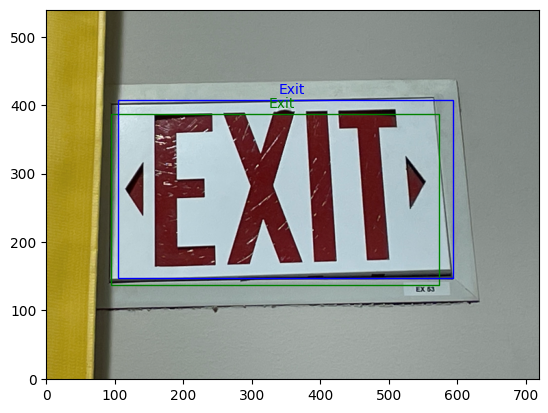

In [ ]:
show_image_v2(image, c, 0, d, 0)